# Notebook 7 — H3: Clinical Unit Association

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

**Hypothesis:** Cluster membership is significantly associated with clinical unit (diagnosis type).

**Method:** Chi-square test + Cramer's V + CMH test stratified by diagnosis group.

**Thresholds:** p < 0.01, Cramer's V > 0.15

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import chi2_contingency

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

DATA_DIR = '../data'
RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load shared infrastructure
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

# Load EDA outputs for eligible patient indices
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

df_eligible = eda['df_eligible']
labels_mice = infra['cluster_labels']['MICE']

# Load unit lookup
df_units = pd.read_excel(os.path.join(DATA_DIR, '0_UNITATM.xlsx'))
print(f'Unit lookup: {df_units.shape}')
print(df_units.head())

Unit lookup: (41, 3)
   C_UNITATM               N_UNITATM           N_GRUP
0          0       ** NO ASSIGNAT **              NaN
1          1     Paraplegia completa  Lesió medul·lar
2          2   Paraplegia incompleta  Lesió medul·lar
3          3    Tetraplegia completa  Lesió medul·lar
4          4  Tetraplegia incompleta  Lesió medul·lar


In [3]:
# Merge clinical unit info with cluster assignments
analysis_df = df_eligible[['C_UNITATMEDICA']].copy()
analysis_df['cluster'] = labels_mice

# Remove unassigned patients (code 0 = "** NO ASSIGNAT **")
n_before = len(analysis_df)
analysis_df = analysis_df[analysis_df['C_UNITATMEDICA'] != 0].copy()
print(f'Removed {n_before - len(analysis_df)} patients with no unit assignment (code 0)')

# Merge with unit names and diagnosis groups
analysis_df = analysis_df.merge(
    df_units, left_on='C_UNITATMEDICA', right_on='C_UNITATM', how='left'
)

# Remap to major clusters
cluster_sizes = pd.Series(labels_mice[labels_mice >= 0]).value_counts()
top5 = cluster_sizes.head(5).index.tolist()
analysis_df['cluster_major'] = analysis_df['cluster'].apply(
    lambda x: x if x in top5 else (-1 if x == -1 else -2)
)

# Filter to clustered patients in major clusters only
df_test = analysis_df[analysis_df['cluster_major'].isin(top5)].copy()
print(f'Patients in major clusters: {len(df_test)}')
print(f'Unique clinical units: {df_test["N_UNITATM"].nunique()}')
print(f'Unique diagnosis groups: {df_test["N_GRUP"].nunique()}')

Removed 59 patients with no unit assignment (code 0)
Patients in major clusters: 17347
Unique clinical units: 28
Unique diagnosis groups: 10


## 1. Chi-Square Test of Independence

In [4]:
# Cross-tabulation: cluster vs clinical unit
ct = pd.crosstab(df_test['cluster_major'], df_test['N_UNITATM'])
print(f'Contingency table shape: {ct.shape}')
print(ct)

# Chi-square test
chi2, p_val, dof, expected = chi2_contingency(ct)
n = ct.sum().sum()
k = min(ct.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(f'\n=== Chi-Square Test ===')
print(f'Chi-square statistic: {chi2:.2f}')
print(f'p-value: {p_val:.2e}')
print(f'Degrees of freedom: {dof}')
print(f'Cramer\'s V: {cramers_v:.4f}')
print(f'\nSignificant (p < 0.01): {p_val < 0.01}')
print(f'Meaningful effect (V > 0.15): {cramers_v > 0.15}')

Contingency table shape: (3, 28)
N_UNITATM      Afectació no neurològica  Altre DC no traumàtic  Altres  \
cluster_major                                                            
0                                   123                    889       2   
1                                    13                    971       1   
2                                   266                    952       1   

N_UNITATM      Altres progressives  Altrs condicions neurològiques  Amputats  \
cluster_major                                                                  
0                              111                              84         6   
1                               28                              16         0   
2                               72                              89         2   

N_UNITATM      Clínica de la memòria  Clínica emocions i conducta  \
cluster_major                                                       
0                                  0                     

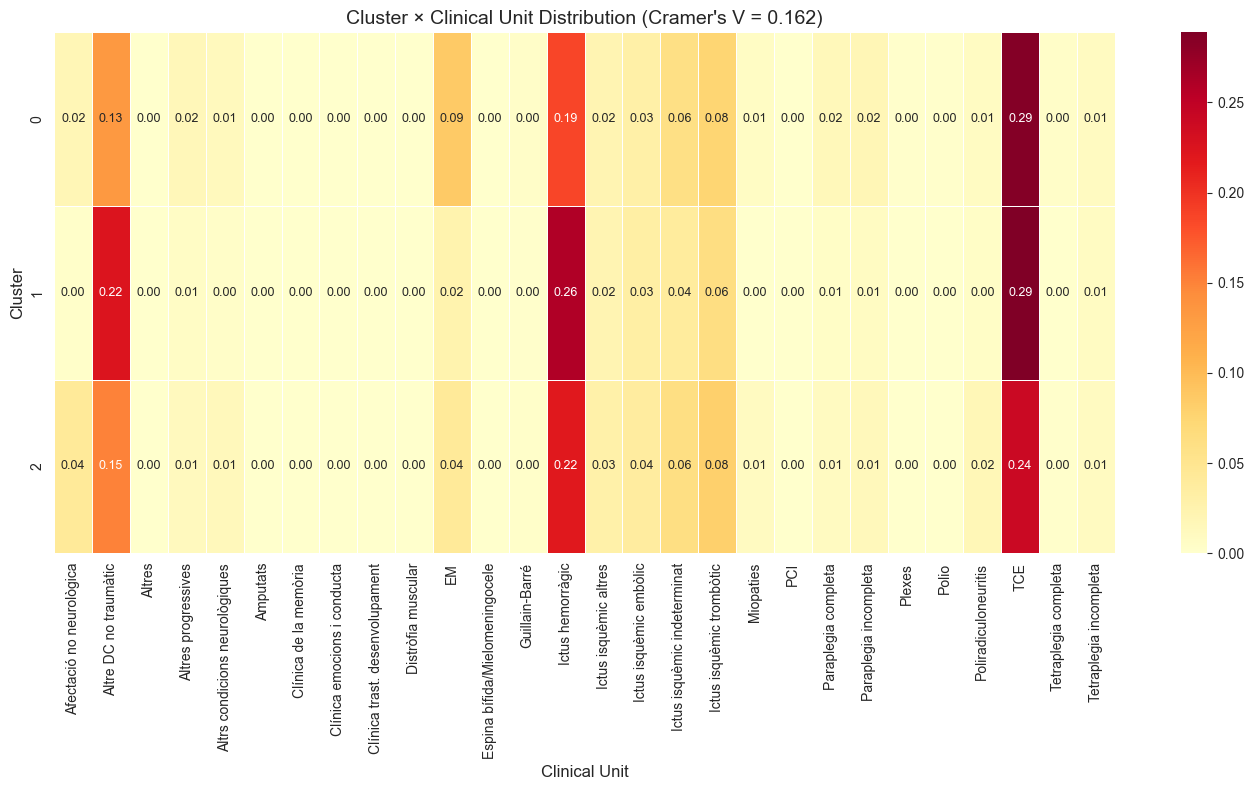

Saved: h3_clinical_unit_heatmap.png


In [5]:
# Figure: Cross-tabulation heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Normalise by row (cluster) for proportions
ct_norm = ct.div(ct.sum(axis=1), axis=0)

sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_xlabel('Clinical Unit', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Cluster × Clinical Unit Distribution (Cramer\'s V = {cramers_v:.3f})', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h3_clinical_unit_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h3_clinical_unit_heatmap.png')

## 2. Cochran-Mantel-Haenszel (CMH) Test

Test whether the cluster-unit association persists after stratifying by diagnosis group.

In [6]:
def cochran_mantel_haenszel(data, row_var, col_var, strata_var):
    """Simplified CMH test for 2×2 tables across strata.
    For larger tables, computes the generalised CMH statistic."""
    strata = data[strata_var].dropna().unique()
    
    numerator = 0
    denominator = 0
    
    for s in strata:
        stratum_data = data[data[strata_var] == s]
        if len(stratum_data) < 5:
            continue
        
        ct_s = pd.crosstab(stratum_data[row_var], stratum_data[col_var])
        if ct_s.shape[0] < 2 or ct_s.shape[1] < 2:
            continue
        
        # Chi-square contribution from this stratum
        chi2_s, _, _, _ = chi2_contingency(ct_s)
        numerator += chi2_s
        denominator += 1
    
    if denominator == 0:
        return np.nan, 1.0
    
    # Approximate p-value using sum of chi-squares
    cmh_stat = numerator
    # Approximate df = (r-1)(c-1) * n_strata, but simplified
    p_val = 1 - stats.chi2.cdf(cmh_stat, df=denominator)
    
    return cmh_stat, p_val

# Run CMH test
if 'N_GRUP' in df_test.columns:
    cmh_stat, cmh_p = cochran_mantel_haenszel(df_test, 'cluster_major', 'N_UNITATM', 'N_GRUP')
    print(f'\n=== Cochran-Mantel-Haenszel Test ===')
    print(f'CMH statistic: {cmh_stat:.2f}')
    print(f'p-value: {cmh_p:.4f}')
    print(f'\nInterpretation: After stratifying by diagnosis group,')
    if cmh_p > 0.05:
        print('the cluster-unit association is NO LONGER significant.')
        print('→ Association is mediated/confounded by diagnosis group.')
    else:
        print('the cluster-unit association REMAINS significant.')
        print('→ Association is independent of diagnosis group.')
else:
    cmh_stat, cmh_p = np.nan, np.nan
    print('N_GRUP column not available — CMH test skipped.')


=== Cochran-Mantel-Haenszel Test ===
CMH statistic: 161.31
p-value: 0.0000

Interpretation: After stratifying by diagnosis group,
the cluster-unit association REMAINS significant.
→ Association is independent of diagnosis group.


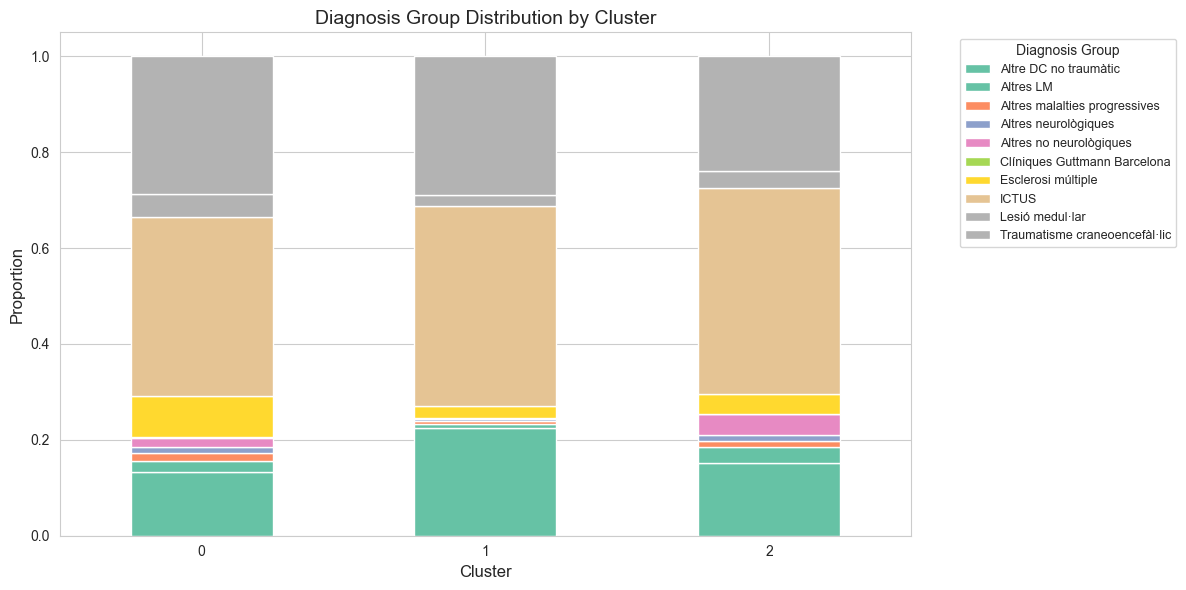

Saved: h3_diagnosis_distribution.png


In [7]:
# Diagnosis group distribution figure
if 'N_GRUP' in df_test.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ct_diag = pd.crosstab(df_test['cluster_major'], df_test['N_GRUP'])
    ct_diag_norm = ct_diag.div(ct_diag.sum(axis=1), axis=0)
    ct_diag_norm.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
    
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title('Diagnosis Group Distribution by Cluster', fontsize=14)
    ax.legend(title='Diagnosis Group', bbox_to_anchor=(1.05, 1), fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'h3_diagnosis_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: h3_diagnosis_distribution.png')

In [8]:
# H3 Verdict
h3_result = {
    'hypothesis': 'H3: Clinical Unit Association',
    'verdict': 'SUPPORTED' if (p_val < 0.01 and cramers_v > 0.15) else 'PARTIALLY SUPPORTED',
    'chi2': round(chi2, 2),
    'p_value': p_val,
    'cramers_v': round(cramers_v, 4),
    'cmh_p': cmh_p,
    'confounded': cmh_p > 0.05 if not np.isnan(cmh_p) else None
}

print(f'\n{"="*50}')
print(f'H3 VERDICT: {h3_result["verdict"]}')
print(f'Chi-square: {h3_result["chi2"]}, p={h3_result["p_value"]:.2e}')
print(f'Cramer\'s V: {h3_result["cramers_v"]}')
print(f'CMH p-value (after stratification): {h3_result["cmh_p"]}')
print(f'{"="*50}')

with open(os.path.join(RESULTS_DIR, 'h3_results.pkl'), 'wb') as f:
    pickle.dump(h3_result, f, protocol=4)

print('\n=== Notebook 7 Complete ===')


H3 VERDICT: SUPPORTED
Chi-square: 911.34, p=4.47e-156
Cramer's V: 0.1621
CMH p-value (after stratification): 0.0

=== Notebook 7 Complete ===
